<a href="https://colab.research.google.com/github/Anshu-kumar-singh/DL_From_scratch/blob/main/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Activation Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# How much should the output neuron change
def sigmoid_derivative(a):# dZ2​=(A2​−y)σ′(Z2​)
    # a is already sigmoid(z), so derivative = a * (1 - a)
    return a * (1 - a)

class SimpleANN:
    def __init__(self, n_input, n_hidden, n_output, lr=0.1):
        # Input -> Hidden Layer
        self.W1 = np.random.randn(n_input, n_hidden) * 0.1
        self.b1 = np.zeros((1, n_hidden))
        # Hidden -> Output Layer
        self.W2 = np.random.randn(n_hidden, n_output) * 0.1
        self.b2 = np.zeros((1, n_output))
        self.lr = lr

    def forward(self, X):
        # Layer 1
        self.Z1 = np.dot(X, self.W1) + self.b1 # Z1​=XW1​+b1​
        self.A1 = sigmoid(self.Z1) # calling the activation function
        # Layer 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2 # Z2​=A1​W2​+b2​
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]  # number of samples, used to average gradients

        # Output layer error
        dZ2 = (self.A2 - y) * sigmoid_derivative(self.A2)   # (self.A2 - y) this tells the diff btw the actual answer and predicted answer then the function function call in this line tell how much we have to change the neuron value
        # Gradient of W2
        dW2 = np.dot(self.A1.T, dZ2) / m                    # dW2​=A1^T​dZ2​​ / m
        # Output neuron

         # Hidden Output
               #│
               #▼
              #Weight
               #│
               #▼
              #Output

          # Each hidden neuron contributes to the output.
          # We need to know
          # How much is each weight responsible for the error?"
        # Gradient of Output Bias
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Send Error Backward

        dA1 = np.dot(dZ2, self.W2.T)  # dA1​=dZ2​W2T​
        # The output neuron tells every hidden neuron how much it contributed to the error.

        dZ1 = dA1 * sigmoid_derivative(self.A1)#Hidden Layer Error
        # Gradient of W1
        dW1 = np.dot(X.T, dZ1) / m
        #Gradient of Hidden Bias
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---- Gradient Descent update (Update Output Weights)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=10000):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y)

            if epoch % 1000 == 0:
                loss = np.mean((output - y) ** 2)
                print(f"Epoch {epoch}, Loss: {loss:.4f}")


# Input Data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target Output (XOR problem)
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

model = SimpleANN(2, 4, 1, lr=0.5)

print("Before training:")
print(model.forward(X))

model.train(X, y, epochs=10000)

print("\nAfter training:")
print(model.forward(X))

 * Gradient of Output Bias

 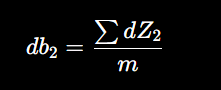

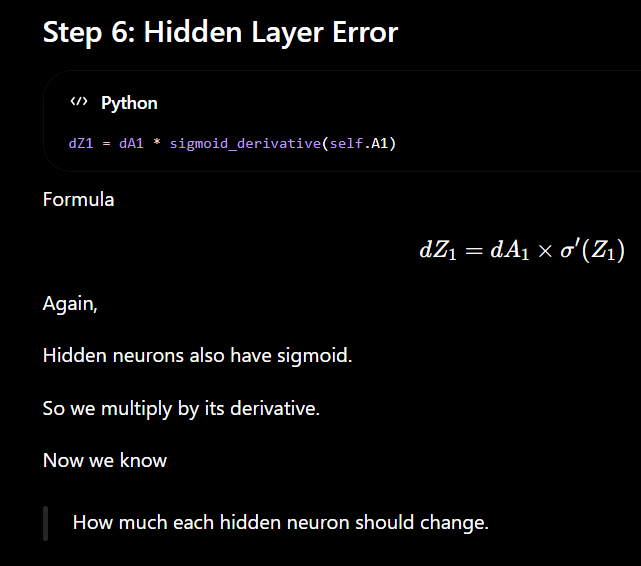